In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from CIBUSmod.impact.LULUC import LUCTimeSeries

In [8]:
session = cm.Session(
    name = 'MFF',
    data_path = '../data',
    data_path_output = '../../MFF-scenarios/output'
)

In [17]:
session.get_attr('C','area','none',interpolate=True)

TypeError: can only concatenate str (not "int") to str

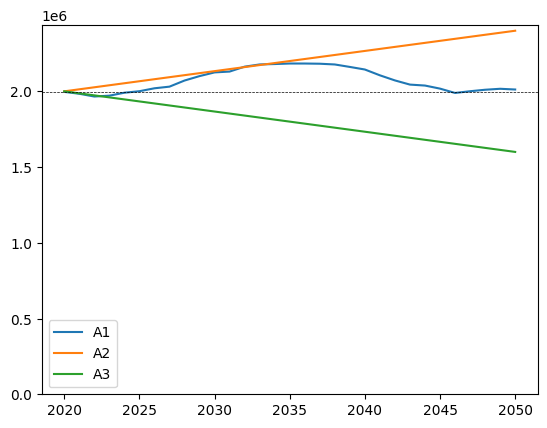

In [4]:
import matplotlib.pyplot as plt

# Generate land use time series
A = {}
A0 = 2_000_000
At = A0
for t in range(2020,2050+1):
    Ach = -np.sin(t/4)*(A0/100) + np.random.randn()*(A0/100/2)
    At += Ach
    A.update({t:At})
    
A1 = pd.Series(A)
A2 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*1.2,31))})
A3 = pd.Series({y:At for y,At in zip(range(2020,2050+1),np.linspace(A0,A0*0.8,31))})

ax = A1.plot(label='A1')
A2.plot(ax=ax, label='A2')
A3.plot(ax=ax, label='A3')
ax.axhline(A1.iloc[0], color='black', linestyle='--',linewidth=0.5)
ax.set_ylim(0)
ax.legend()
plt.show()

In [5]:
Ach = A1.diff().fillna(0)
LUCts = LUCTimeSeries(
    Ach = Ach,
    Cmax = (5_000,50_000),
    T50 = (0.5,20),
    extend = 100
)
LUCts.calculate_parcels()

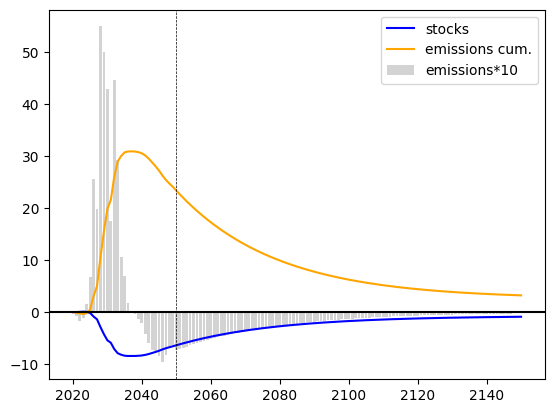

In [6]:
stocks = LUCts.get_stocks() / 1_000_000_000
emissions = LUCts.get_CO2() / 1_000_000_000
ax = stocks.plot(label='stocks', color='blue')
ax.bar(emissions.index, emissions*10, label='emissions*10', color='lightgrey')
emissions.cumsum().plot(label='emissions cum.', color='orange', ax=ax)
ax.axhline(0, color='black')
ax.axvline(2050, color='black', linestyle='--', linewidth=0.5)
ax.legend()
